In [ ]:

# Introduction to ChatGPT and Language Models
#   • ChatGPT is a probabilistic language model that generates text sequentially based on
# input prompts.
#   • It can produce multiple different plausible outputs for the same prompt due to its
# probabilistic nature.
#   • Language models predict the next word or token in a sequence by modeling the
# likelihood of word order in natural language.
# ChatGPT operates at the token level, which are subword units, unlike a character-level model.

# https://arxiv.org/pdf/1706.03762

# Transformer Architecture Background
#   • The Transformer architecture, introduced in the 2017 paper “Attention Is All You Need,”
# underpins ChatGPT.
#   • GPT stands for Generative Pre-trained Transformer; the Transformer is the neural network 
# responsible for modeling sequences of tokens.
#   • Transformer revolutionized AI by enabling efficient sequence modeling without relying on 
# recurrent or convolutional networks.
#   • The video focuses on building a simpler character-level language model using a Transformer
#         on the Tiny Shakespeare dataset (~1MB text corpus).


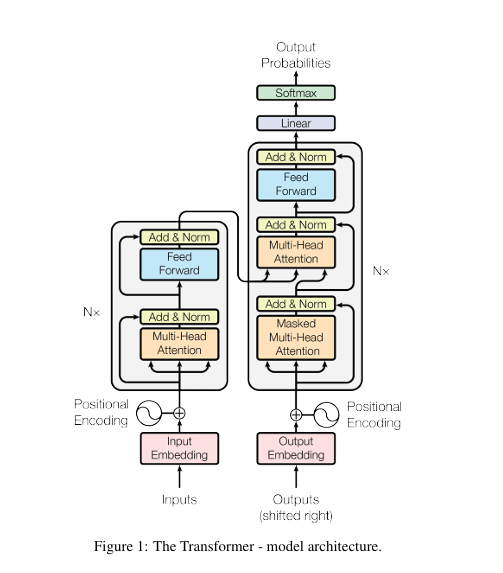

In [3]:
	# https://arxiv.org/pdf/1706.03762

# Transformer Architecture Background
#   • The Transformer architecture, introduced in the 2017 paper “Attention Is All You Need,”
# underpins ChatGPT.
#   • GPT stands for Generative Pre-trained Transformer; the Transformer is the neural network 
# responsible for modeling sequences of tokens.
#   • Transformer revolutionized AI by enabling efficient sequence modeling without relying on 
# recurrent or convolutional networks.
#   • The video focuses on building a simpler character-level language model using a Transformer
#         on the Tiny Shakespeare dataset (~1MB text corpus).
# https://arxiv.org/pdf/1706.03762
from IPython.display import Image, display
display(Image(filename='transformer.png'))

# Transformer Architecture Background
#   • The Transformer architecture, introduced in the 2017 paper “Attention Is All You Need,”
# underpins ChatGPT.
#   • GPT stands for Generative Pre-trained Transformer; the Transformer is the neural network 
# responsible for modeling sequences of tokens.
#   • Transformer revolutionized AI by enabling efficient sequence modeling without relying on 
# recurrent or convolutional networks.
#   • The video focuses on building a simpler character-level language model using a Transformer
#         on the Tiny Shakespeare dataset (~1MB text corpus).
# https://arxiv.org/pdf/1706.03762


In [6]:
# import requests
# url = ' https://github.com/karpathy/ng-video-lecture/blob/master/input.txt'
# output_file = 'input.txt'
# response = requests.get(url)
# with open(output_file, 'wb') as f:
#     f.write(response.content)
# print(f"Downloaded {output_file}")


In [7]:
with open('input.txt' , 'r',encoding='utf-8') as f:
    text = f.read()


In [132]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [133]:


print(text[:1000])


First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [134]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [135]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [136]:
import tiktoken 
print(tiktoken.__version__)
enc = tiktoken.get_encoding('gpt2')
print(enc.n_vocab)


0.11.0
50257


In [137]:
import tiktoken 
print(tiktoken.__version__)
enc = tiktoken.get_encoding('gpt2')
print(enc.n_vocab)
enc.decode([71,4178,612])


0.11.0
50257


'hii there'

In [138]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [139]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [140]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [141]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [22]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53

In [23]:
print(xb) # our input to the transformer

tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])


In [ ]:
# Implementing and Training a Simple Bigram Language Model
# 	• Initial implementation is a Bigram Language Model: a simple lookup embedding 
# table where the prediction of the next token depends only on the current token identity,
# without context interaction.
# 	• Logits are generated by embedding indices and interpreted as scores for the next character.
# 	• Cross-entropy loss (negative log-likelihood) is used to measure prediction quality.
# 	• Model training uses the Adam optimizer with a learning rate tuned for small models, 
# training on batched data samples.
# 	• After training for thousands of iterations, the loss decreases, but the model only
# captures very local character dependencies without context understanding.


In [42]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    def forward(self, idx, targets=None):
        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)
        return logits
        
m = BigramLanguageModel(vocab_size)
out = m(xb,yb)
print(out.shape)
	#     if targets is None:
    #         loss = None
    #     else:
    #         B, T, C = logits.shape
    #         logits = logits.view(B*T, C)
    #         targets = targets.view(B*T)
    #         loss = F.cross_entropy(logits, targets)
	#     return logits, loss
	# def generate(self, idx, max_new_tokens):
    #     # idx is (B, T) array of indices in the current context
    #     for _ in range(max_new_tokens):
    #         # get the predictions
    #         logits, loss = self(idx)
    #         # focus only on the last time step
    #         logits = logits[:, -1, :] # becomes (B, C)
    #         # apply softmax to get probabilities
    #         probs = F.softmax(logits, dim=-1) # (B, C)
    #         # sample from the distribution
    #         idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
    #         # append sampled index to the running sequence
#             idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
#         return idx
	# m = BigramLanguageModel(vocab_size)
# logits, loss = m(xb, yb)
# print(logits.shape)
# print(loss)
# print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

torch.Size([4, 8, 65])


In [50]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    def forward(self, idx, targets):
	# idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = targets.view(B*T)
        loss = F.cross_entropy(logits, targets)
        return logits,loss 
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)


torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


In [59]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    def forward(self, idx, targets):
	# idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = targets.view(B*T)
        loss = F.cross_entropy(logits, targets)
        return logits ,loss
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)


torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


In [66]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    def forward(self, idx, targets):
	# idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits ,loss
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)


torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


In [73]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    def forward(self, idx, targets):
	# idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
            
        return logits ,loss
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)
#idx = torch.zeros((1, 1), dtype=torch.long
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


TypeError: BigramLanguageModel.forward() missing 1 required positional argument: 'targets'

In [74]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)

SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ


In [ ]:
done till 33:00

In [75]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [116]:
batch_size = 32
for steps in range(100): # increase number of steps for good results...
#for steps in range(10000):

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    #print(loss.item())

print(loss.item())


2.549032211303711


In [78]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


ARICI fere yothar highe LUSeppe y chan d a t, hif nes,
Pl peORjulaliseel E Lo sot.
Ouprco,
Areke ath


In [79]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=300)[0].tolist()))


USAnghars s NCHO:
Cieneedevee, ESons, s ffaye nencawhe;
UThis thoo lfantentROR: scor ce athecre yealldil:
Sourorir Goban o ishead onshatie cth walot hery I h merd ply this.
TAne bexpimond me stowan ureimy herst P,
N s, orowha whet brtore hilave w wese wedortore 's r Re, nduisstive ly s; bl! br'sitho


In [117]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))


HApo prs te
F:
Of ood haty stris:

NGS: acend bsthy atavealilit hity winndwourd; BENUS:
KAst oven?
Acrere, wnorvelll htethitele thak?
Benhomooopraloto.

CORYSThith sis,
A Yot
H:

An on asdotharesalowhep?ysot bar, de,
Fau, tos torthelo thO,

F:
mmikerand:
MO:
TENow n thagok tororompenor, hey:
CHave;
Ang tsw
Ashif yewal the yotd the bre, tharolisesue t takence rancughtok bent,
Ther o p stn?f ithan ar tour t the o we tw n t thines athe M:
NRofubenerut:
FFicaUCHaherbyou m, wouteheretofr:
The ouk de 


In [ ]:
# shift all the code to biagram.py

In [ ]:
# Adding Positional Information and Preparing For Self-Attention
# 	• Embeddings are expanded to include positional embeddings to encode token position 
# information, crucial for sequence understanding since attention mechanisms are position-agnostic.
# 	• The simple Bigram model is extended to add token embeddings and positional embeddings 
# summed together as input to subsequent layers.
# 	• To handle longer contexts, the block size is increased, and the model is set up to manage
# sequences within this fixed maximum length.


In [ ]:
#  Introduction to Self-Attention and Efficient Implementation
# 	• Self-attention allows tokens in a sequence to communicate by weighting and aggregating
# information from previous tokens, respecting causality (future tokens cannot influence past tokens).
# 	• A naive approach averages all previous tokens equally, which loses spatial/token order information.
# 	• Efficient implementation uses matrix multiplication with a lower-triangular mask to ensure causal attention.
# 	• Softmax and masking are applied to the affinity matrix so that attention weights are data-dependent
# and normalized across allowable tokens.
# 	• This mechanism computes weighted sums of value vectors, where queries represent what a token 
# is looking for and keys represent what each token contains.


In [105]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [106]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)

In [107]:
x

tensor([[[ 0.1808, -0.0700],
         [-0.3596, -0.9152],
         [ 0.6258,  0.0255],
         [ 0.9545,  0.0643],
         [ 0.3612,  1.1679],
         [-1.3499, -0.5102],
         [ 0.2360, -0.2398],
         [-0.9211,  1.5433]],

        [[ 1.3488, -0.1396],
         [ 0.2858,  0.9651],
         [-2.0371,  0.4931],
         [ 1.4870,  0.5910],
         [ 0.1260, -1.5627],
         [-1.1601, -0.3348],
         [ 0.4478, -0.8016],
         [ 1.5236,  2.5086]],

        [[-0.6631, -0.2513],
         [ 1.0101,  0.1215],
         [ 0.1584,  1.1340],
         [-1.1539, -0.2984],
         [-0.5075, -0.9239],
         [ 0.5467, -1.4948],
         [-1.2057,  0.5718],
         [-0.5974, -0.6937]],

        [[ 1.6455, -0.8030],
         [ 1.3514, -0.2759],
         [-1.5108,  2.1048],
         [ 2.7630, -1.7465],
         [ 1.4516, -1.5103],
         [ 0.8212, -0.2115],
         [ 0.7789,  1.5333],
         [ 1.6097, -0.4032]]])

In [108]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [109]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [ ]:
# m tokens from my current sequence and then I'm just doing the average or the mean over the zero Dimension so I'm averaging out the time here and I'm just going to get a little c one dimensional Vector which I'm going to store in X bag of words so I can run this and and uh this is not going to be very informative because let's see so this is X of Zer so this is the zeroth batch element and then expo at zero now you see how the at the first location here you see that the two are equal and that's because it's
# we're just doing an average of this one token but here this one is now an average of these two and now this one is an average of these three and so on so uh and this last one is the average of all of these elements so vertical average just averaging up all the tokens now gives this outcome here so this is all well and good uh but this is very inefficient now the trick is that we can be very very efficient about doing this using matrix multiplication so that's the mathematical trick and let me show you




In [89]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
a = torch.ones(3, 3)
#a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[14., 16.],
        [14., 16.],
        [14., 16.]])


In [90]:
# what I mean let's work with the toy example here let me run it and I'll explain I have a simple Matrix here that is a 3X3 of all ones a matrix B of just random numbers and it's a 3x2 and a matrix C which will be 3x3 multip 3x2 which will give out a 3x2 so here we're just using um matrix multiplication so a multiply B gives us C okay so how are these numbers in C um achieved right so this number in the top left is the first row of a dot product with the First Column of B and since all
# the the row of a right now is all just ones then the do product here with with this column of B is just going to do a sum of these of this column so 2 + 6 + 6 is 14 the element here in the output of C is also the first column here the first row of a multiplied now with the second column of B so 7 + 4 + 5 is 16 now you see that there's repeating elements here so this 14 again is because this row is again all ones and it's multiplying the First Column of B so we get 14 and this one is and so on so this last number
torch.tril(torch.ones(3, 3))

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

In [92]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
#a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[ 2.,  7.],
        [ 8., 11.],
        [14., 16.]])


In [ ]:
# here is the last row do product last column now the trick here is uh the following this is just a boring number of um it's just a boring array of all ones but torch has this function called Trail which is short for a triangular uh something like that and you can wrap it in torch up once and it will just return the lower triangular portion of this okay so now it will basically zero out uh these guys here so we just get the lower triangular part well what happens if we do that so now we'll have a like this and B
# like this and now what are we getting here in C well what is this number well this is the first row times the First Column and because this is zeros uh these elements here are now ignored so we just get a two and then this number here is the first row times the second column and because these are zeros they get ignored and it's just seven this seven multiplies this one but look what happened here because this is one and then zeros we what ended up happening is we're just plucking out the
# row of this row of B and that's what we got now here we have one 1 Z so here 110 do product with these two columns will now give us 2 + 6 which is 8 and 7 + 4 which is 11 and because this is 111 we ended up with the addition of all of them and so basically depending on how many ones and zeros we have here we are basically doing a sum currently of a variable number of these rows and that gets deposited into C So currently we're doing sums because these are ones but we can also do average right and you can start to see


In [155]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [156]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [157]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)

In [158]:
# version 2: using matrix multiply for a weighted aggregation
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
torch.allclose(xbow, xbow2)
#ouput should be true

False

In [161]:
# version 2: using matrix multiply for a weighted aggregation
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
wei
#xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
#torch.allclose(xbow, xbow2)
#ouput should be true

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [130]:
#xbow , xbow2
xbow[0],xbow2[0]

(tensor([[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]]),
 tensor([[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]]))

In [162]:
# version 3: use Softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)
#output true

False

In [163]:
tril

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

In [165]:
wei = torch.zeros((T,T))
wei

tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [166]:
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [167]:
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [169]:
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)
#output should be true 

False

In [171]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
# head_size = 16
# key = nn.Linear(C, head_size, bias=False)
# query = nn.Linear(C, head_size, bias=False)
# value = nn.Linear(C, head_size, bias=False)
# k = key(x)   # (B, T, 16)
# q = query(x) # (B, T, 16)
# wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

#v = value(x)
#out = wei @ v
out = wei @ x

out.shape

torch.Size([4, 8, 32])

In [ ]:
# Implementing Single-Head Self-Attention
# 	• Each token produces three vectors: query (Q), key (K), and value (V) via learned 
# linear projections from the embeddings.
# 	• Attention weights are computed as scaled dot-products of queries and keys, followed 
# by masking (to prevent attending to future tokens) and softmax normalization.
# 	• The weighted sum of the value vectors yields the output of the attention head.
# 	• This mechanism enables tokens to dynamically focus on relevant parts of the past context.
# 	• Scaled dot-product attention uses a normalization factor (1/√head_size) to stabilize
#     gradients and prevent overly peaky softmax outputs at initialization.


In [178]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
# value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

#v = value(x)
#out = wei @ v
out = wei @ x

out.shape

torch.Size([4, 8, 32])

In [179]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [180]:
wei

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
         [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
         [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
         [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1687, 0.8313, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2477, 0.0514, 0.7008, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4410, 0.0957, 0.3747, 0.0887, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0069, 0.0456, 0.0300, 0.7748, 0.1427, 0.0000, 0.0000, 0.0000],
         [0.0660, 0.089

In [181]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
# value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
#wei = wei.masked_fill(tril == 0, float('-inf'))
#wei = F.softmax(wei, dim=-1)

#v = value(x)
#out = wei @ v
out = wei @ x

out.shape

torch.Size([4, 8, 32])

In [182]:
wei[0]

tensor([[-1.7629, -1.3011,  0.5652,  2.1616, -1.0674,  1.9632,  1.0765, -0.4530],
        [-3.3334, -1.6556,  0.1040,  3.3782, -2.1825,  1.0415, -0.0557,  0.2927],
        [-1.0226, -1.2606,  0.0762, -0.3813, -0.9843, -1.4303,  0.0749, -0.9547],
        [ 0.7836, -0.8014, -0.3368, -0.8496, -0.5602, -1.1701, -1.2927, -1.0260],
        [-1.2566,  0.0187, -0.7880, -1.3204,  2.0363,  0.8638,  0.3719,  0.9258],
        [-0.3126,  2.4152, -0.1106, -0.9931,  3.3449, -2.5229,  1.4187,  1.2196],
        [ 1.0876,  1.9652, -0.2621, -0.3158,  0.6091,  1.2616, -0.5484,  0.8048],
        [-1.8044, -0.4126, -0.8306,  0.5899, -0.7987, -0.5856,  0.6433,  0.6303]],
       grad_fn=<SelectBackward0>)

In [185]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
# value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
#wei = F.softmax(wei, dim=-1)

#v = value(x)
#out = wei @ v
out = wei @ x

out.shape

torch.Size([4, 8, 32])

In [186]:
wei[0]

tensor([[-1.7629,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-3.3334, -1.6556,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-1.0226, -1.2606,  0.0762,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.7836, -0.8014, -0.3368, -0.8496,    -inf,    -inf,    -inf,    -inf],
        [-1.2566,  0.0187, -0.7880, -1.3204,  2.0363,    -inf,    -inf,    -inf],
        [-0.3126,  2.4152, -0.1106, -0.9931,  3.3449, -2.5229,    -inf,    -inf],
        [ 1.0876,  1.9652, -0.2621, -0.3158,  0.6091,  1.2616, -0.5484,    -inf],
        [-1.8044, -0.4126, -0.8306,  0.5899, -0.7987, -0.5856,  0.6433,  0.6303]],
       grad_fn=<SelectBackward0>)

In [189]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
# value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

#v = value(x)
#out = wei @ v
out = wei @ x

out.shape

torch.Size([4, 8, 32])

In [190]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [192]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [193]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [194]:
# Notes:

# Attention is a communication mechanism. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
# There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
# Each example across batch dimension is of course processed completely independently and never "talk" to each other
# In an "encoder" attention block just delete the single line that does masking with tril,
#allowing all tokens to communicate. This block here is called a "decoder" attention block 
#because it has triangular masking, and is usually used in autoregressive settings, like
#language modeling.
# "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)
# "Scaled" attention additional divides wei by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

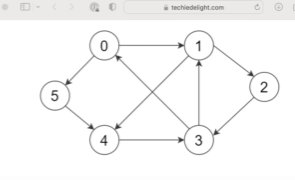

In [195]:
from IPython.display import Image, display
display(Image(filename='graph.png'))

In [ ]:
 # Implementing Single-Head Self-Attention
	# • Each token produces three vectors: query (Q), key (K), and value (V) via learned linear projections from the embeddings.
	# • Attention weights are computed as scaled dot-products of queries and keys, followed by masking (to prevent attending to future tokens) and softmax normalization.
	# • The weighted sum of the value vectors yields the output of the attention head.
	# • This mechanism enables tokens to dynamically focus on relevant parts of the past context.
	# • Scaled dot-product attention uses a normalization factor (1/√head_size) to stabilize gradients and prevent overly peaky softmax outputs at initialization.


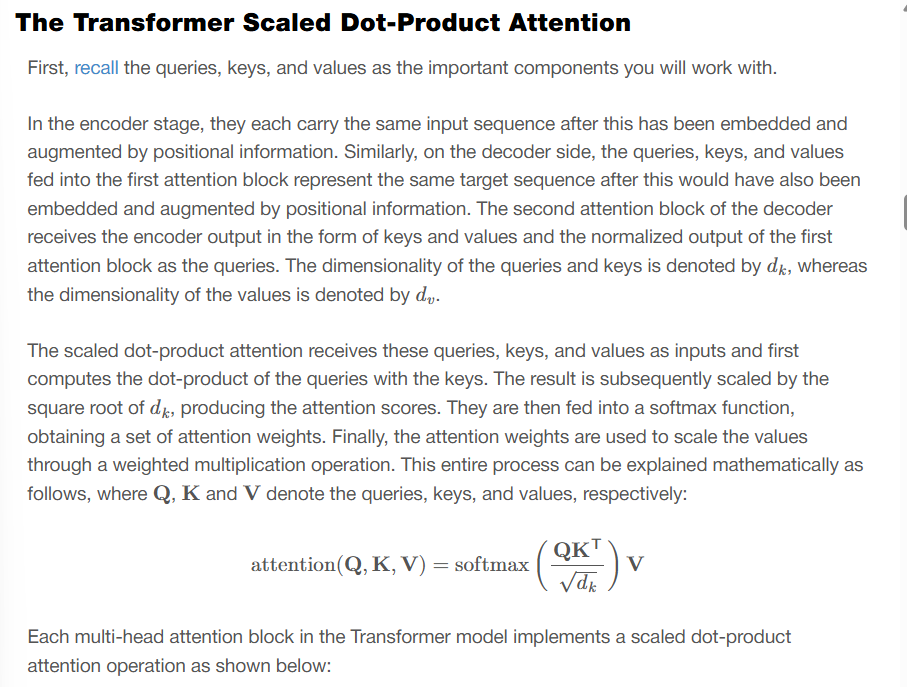

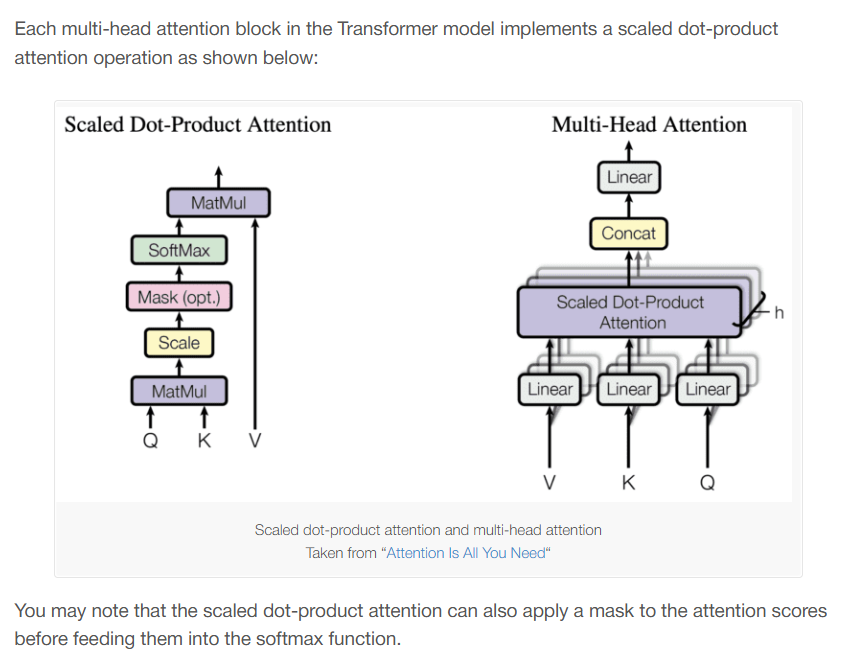

In [197]:
from IPython.display import Image, display
display(Image(filename='scaledprod1.png'))
display(Image(filename='scaledprod2.png'))

In [198]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [199]:
k.var()

tensor(1.0449)

In [200]:
q.var()

tensor(1.0700)

In [201]:
wei.var()

tensor(1.0918)

In [202]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])

In [203]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1) # gets too peaky, converges to one-hot

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

In [ ]:
done till 1:18:14 

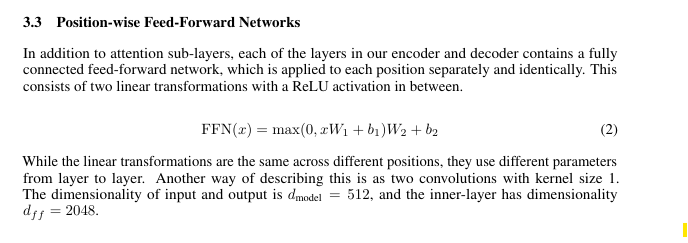

In [205]:
#multi-head attention --> biagram.py

 # Adding Feed-Forward Layers and Deeper Transformer Blocks
	# • After self-attention, tokens independently process aggregated information through a per-token feed-forward network (a small MLP with ReLU activation).
	# • Alternating blocks of multi-headed self-attention and feed-forward networks form the basic Transformer block.
	# • This interspersing of communication and computation enhances model capacity and learning.
	# • Initial deeper models face optimization challenges addressed by residual connections and normalization.
from IPython.display import Image, display
display(Image(filename='ps1.png'))

In [206]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

In [207]:
x[:,0].mean(), x[:,0].std() # mean,std of one feature across all batch inputs

# Scaling Up the Model and Regularization with Dropout
# 	• Model hyperparameters are scaled up: batch size, block size (context length), embedding dimension, number of heads, and number of layers.
# 	• Dropout regularization is introduced to prevent overfitting by randomly disabling parts of the network during training.
# 	• Larger models trained on GPUs (e.g., A100) reach significantly lower validation loss (~1.48) compared to small models.
# 	• Generated text begins to resemble Shakespearean style, although not always coherent.


(tensor(0.1469), tensor(0.8803))

In [208]:
x[0,:].mean(), x[0,:].std() # mean,std of a single input from the batch, of its features

(tensor(-9.5367e-09), tensor(1.0000))

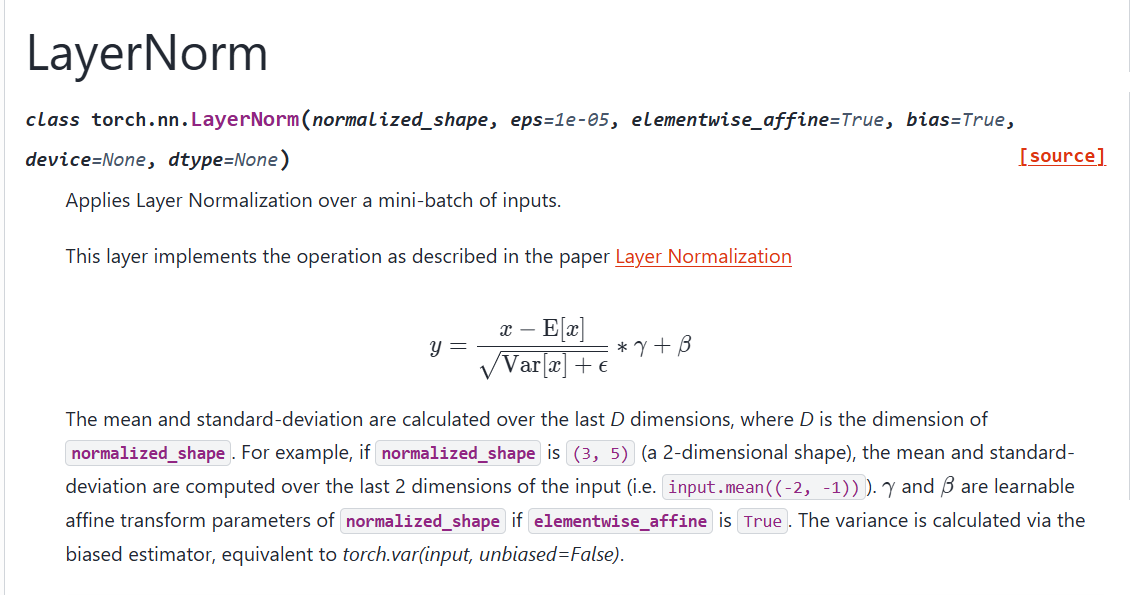

In [209]:
display(Image(filename='ln1.png'))

In [210]:
# Decoder-Only Transformer Architecture vs Encoder-Decoder
# 	• The implemented model is a decoder-only Transformer: it uses masked self-attention to predict the next token autoregressively.
# 	• Original Transformer paper uses an encoder-decoder architecture for machine translation, where the encoder reads input text (e.g., French), and the decoder generates output text (e.g., English) conditioned on the encoded input.
# 	• Encoder has full self-attention without masking; decoder uses masked self-attention plus cross-attention to encoder outputs.
# 	• GPT models are decoder-only since they focus on language modeling (unconditional or conditional text generation).


In [211]:
# French to English translation example:

# <--------- ENCODE ------------------><--------------- DECODE ----------------->
# les réseaux de neurones sont géniaux! <START> neural networks are awesome!<END>


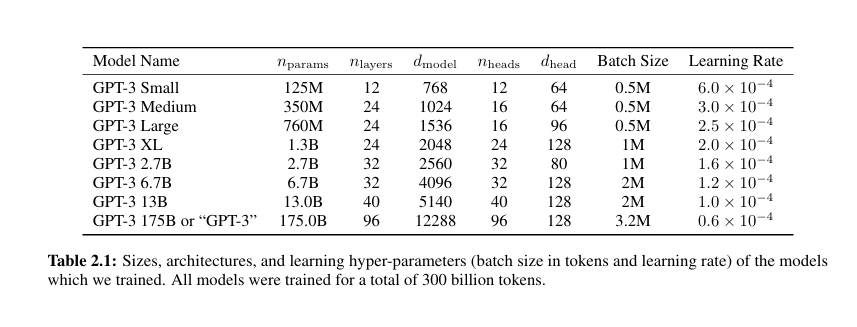

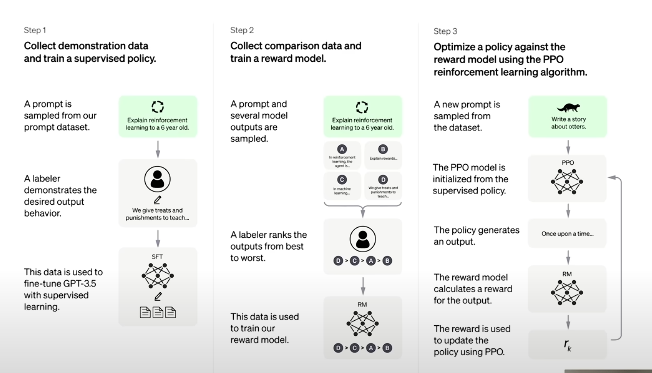

In [213]:
# Overview of NanoGPT Repository and ChatGPT Training Pipeline
# 	• NanoGPT repository contains model.py (Transformer implementation) and train.py (training boilerplate with checkpointing, distributed training, etc.).
# 	• Model.py implements causal self-attention, multi-head attention, feed-forward layers, and positional embeddings, mirroring the tutorial’s Transformer.
# 	• Training large-scale models like GPT-3 involves pre-training on massive datasets (hundreds of billions of tokens) with huge models (hundreds of billions of parameters) and large batch sizes.
# 	• ChatGPT training involves two main stages:
# a) Pre-training: unsupervised training on vast internet text to learn language modeling.
# b) Fine-tuning: supervised and reinforcement learning with human feedback (RLHF) to align the model to be a helpful assistant, involving reward models and policy optimization.
# 	• Fine-tuning data focuses on question-answer pairs, ranking responses, and reinforcement learning to optimize human-preferred behavior.
# 	• This fine-tuning stage is complex and largely proprietary.
#https://arxiv.org/pdf/2005.14165
display(Image(filename='gpt.png'))
display(Image(filename='train.png'))

In [3]:
#https://github.com/karpathy/nanoGPT
import torch
torch.cuda.is_available()

False